In [8]:
# GPU availability check
import torch
import sys

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name())
else:
    print("CUDA is not available")
    print("Available devices:", "CPU only")

Python version: 3.9.22 | packaged by conda-forge | (main, Apr 14 2025, 23:35:59) 
[GCC 13.3.0]
PyTorch version: 2.5.1
CUDA available: False
CUDA is not available
Available devices: CPU only


# PBMC68k NoConstraint Diffusion Analysis - HVG 1024 version (20251014)

This script analyzes the generated samples from the pbmc68k_NoConstraint_20251014_hvg1024 model.

## Overview
- Dataset: PBMC68k
- Model: NoConstraint Diffusion (HVG=1024 genes)
- Date: 2025-10-14

In [9]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sys
import warnings
warnings.filterwarnings('ignore')

# Set up scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

print("Environment set up successfully!")

Environment set up successfully!


## Load Real Data

In [10]:
# Load PBMC68k dataset and apply same preprocessing as in cell_train_20250929_NoConstraint.py
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k.h5ad')

print(f"Original data shape: {adata.shape}")

# Apply the same preprocessing as in cell_train_20250929_NoConstraint.py to match gene filtering
print("Applying preprocessing to match NoConstraint model training...")
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
adata.var_names_make_unique()

print(f"Data shape after filtering: {adata.shape}")
print(f"Available obs columns: {list(adata.obs.columns)}")

Original data shape: (68579, 32738)
Applying preprocessing to match NoConstraint model training...
filtered out 14949 genes that are detected in less than 3 cells
filtered out 14949 genes that are detected in less than 3 cells
Data shape after filtering: (68579, 17789)
Available obs columns: ['TSNE.1', 'TSNE.2', 'celltype', 'n_genes']
Data shape after filtering: (68579, 17789)
Available obs columns: ['TSNE.1', 'TSNE.2', 'celltype', 'n_genes']


## Prepare Real Data for Analysis

In [11]:
# Load PBMC68k dataset and apply same preprocessing as in cell_train_20251014_NoConstraint_hvg1024.py
# Visualization for HVG=1024 (20251014)

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 3  # verbosity level
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Load original PBMC68k dataset
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/data_preparation/pbmc68k.h5ad')
print(f"Original data shape: {adata.shape}")

# Apply the same preprocessing as in cell_train_20251014_NoConstraint_hvg1024.py to match gene filtering
# Apply filtering
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
print(f"Data shape after filtering: {adata.shape}")

# Apply normalization and log transformation  
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Apply HVG selection (same as in training) - HVG 1024 version 20251014
print("Applying HVG selection (1024 genes)...")
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1024,
    subset=True,
    inplace=True
)
print(f"Selected {adata.n_vars} highly variable genes")

print(f"Final preprocessed data shape: {adata.shape}")

Original data shape: (68579, 32738)
filtered out 14949 genes that are detected in less than 3 cells
filtered out 14949 genes that are detected in less than 3 cells
Data shape after filtering: (68579, 17789)
normalizing counts per cell
Data shape after filtering: (68579, 17789)
normalizing counts per cell
    finished (0:00:00)
    finished (0:00:00)
Applying HVG selection (1024 genes)...
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
Applying HVG selection (1024 genes)...
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm

In [12]:
from sklearn.preprocessing import LabelEncoder

# Prepare cell type labels
print('Data shape:', adata.shape)
print('Cell types in dataset:')
print(adata.obs['celltype'].value_counts())

# Encode cell types
classes = adata.obs['celltype'].values
label_encoder = LabelEncoder()
labels = classes
label_encoder.fit(labels)
classes_encoded = label_encoder.transform(labels)

print(f'\nTotal unique cell types: {len(np.unique(labels))}')
print(f'Encoded labels range: {classes_encoded.min()} to {classes_encoded.max()}')

Data shape: (68579, 1024)
Cell types in dataset:
celltype
CD8+ Cytotoxic T                20773
CD8+/CD45RA+ Naive Cytotoxic    16666
CD56+ NK                         8776
CD4+/CD25 T Reg                  6187
CD19+ B                          5908
CD4+/CD45RO+ Memory              3061
CD14+ Monocyte                   2862
Dendritic                        2099
CD4+/CD45RA+/CD25- Naive T       1873
CD34+                             277
CD4+ T Helper2                     97
Name: count, dtype: int64

Total unique cell types: 11
Encoded labels range: 0 to 10


## Load Generated Data from NoConstraint Model

In [13]:
# Load generated samples from NoConstraint HVG1024 model (20251014)
# Visualization for HVG=1024 (20251014)

import numpy as np
import os

# Path to the HVG 1024 version generated samples
unconditional_path = '/home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k_NoConstraint_20251014_hvg1024_1000samples.npz'

print(f"Loading generated samples from: {unconditional_path}")

try:
    # Load generated data
    if os.path.exists(unconditional_path):
        npzfile = np.load(unconditional_path, allow_pickle=True)
        print(f"Available keys in npz file: {list(npzfile.keys())}")
        
        # Extract generated cell data
        cell_gen = npzfile['cell_gen']  # Assuming this is the key for generated cells
        print(f"Generated samples shape: {cell_gen.shape}")
        print(f"Number of generated samples: {cell_gen.shape[0]}")
        print(f"Number of genes: {cell_gen.shape[1]} (HVG 1024)")
        
        # Verify this matches our HVG processing
        if cell_gen.shape[1] == 1024:
            print("✓ Generated data has correct number of HVG genes (1024)")
        else:
            print(f"⚠ Warning: Expected 1024 genes, but got {cell_gen.shape[1]}")
        
        npzfile.close()
        
        print(f"Final generated samples shape: {cell_gen.shape}")
    else:
        print("Failed to load generated samples")
        
except FileNotFoundError:
    print(f"Generated samples file not found at: {unconditional_path}")
    print("Please check if the pbmc68k_NoConstraint_20251014_hvg1024_1000samples.npz file exists")
except Exception as e:
    print(f"Error loading generated samples: {e}")

Loading generated samples from: /home/suzuki/Projects/scDiffusion/output/simulated_samples/pbmc68k_NoConstraint_20251014_hvg1024_1000samples.npz
Available keys in npz file: ['cell_gen']
Generated samples shape: (1000, 1024)
Number of generated samples: 1000
Number of genes: 1024 (HVG 1024)
✓ Generated data has correct number of HVG genes (1024)
Final generated samples shape: (1000, 1024)


Processing generated samples for analysis...
✓ Gene names matched: 1024 genes
Generated data AnnData shape: (1000, 1024)
computing neighbors
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=50
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=50
    finished (0:00:00)
    finished (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
running Leiden clustering
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
running Leiden clustering
    finished: found 4 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: found 4 clusters and added
    'leiden', the cluster labe

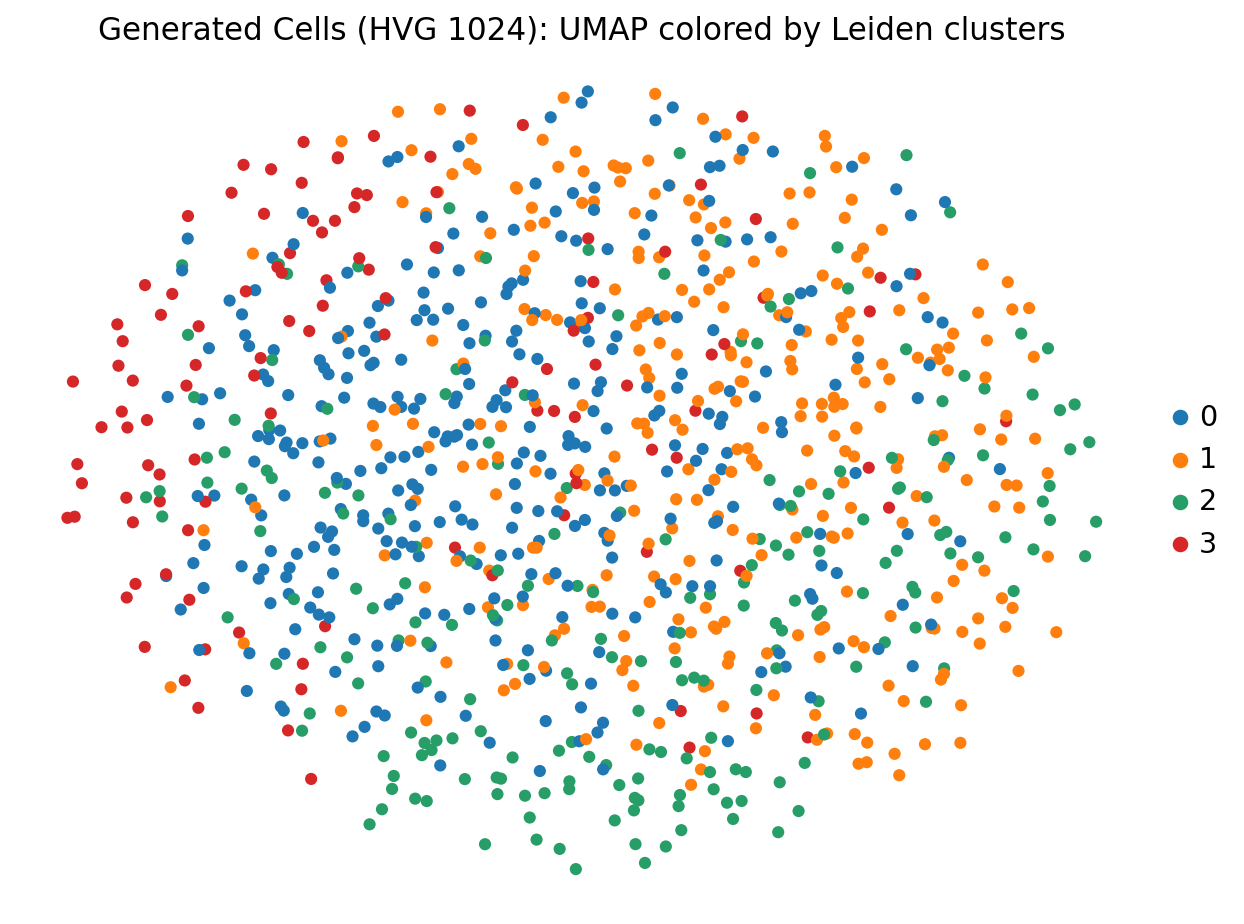

Figure saved to: /home/suzuki/Projects/scDiffusion/exp_result/pbmc68k_NoConstraint_20251014_hvg1024/generated_umap_leiden_hvg1024.png


<Figure size 320x320 with 0 Axes>

In [14]:
# Analyze generated samples - HVG 1024 version (20251014)
# Visualization for HVG=1024 (20251014)

if 'cell_gen' in locals() and cell_gen is not None:
    print("Processing generated samples for analysis...")
    
    # Create AnnData object from generated samples
    import anndata
    
    # Note: Generated samples should already be in the same space as preprocessed real data
    # (normalized, log-transformed, and HVG selected)
    adata_gen = anndata.AnnData(X=cell_gen)
    
    # Use the same gene names from the preprocessed real data
    if adata.n_vars == cell_gen.shape[1]:
        adata_gen.var_names = adata.var_names
        print(f"✓ Gene names matched: {adata_gen.n_vars} genes")
    else:
        print(f"⚠ Gene count mismatch: real={adata.n_vars}, generated={cell_gen.shape[1]}")
        # Use generic gene names
        adata_gen.var_names = [f"Gene_{i}" for i in range(cell_gen.shape[1])]
    
    print(f"Generated data AnnData shape: {adata_gen.shape}")
    
    # Process generated data for visualization
    adata_gen_proc = adata_gen.copy()
    
    # Add some metadata
    adata_gen_proc.obs['source'] = 'generated_hvg1024'
    adata_gen_proc.obs['model'] = 'NoConstraint_HVG1024_20251014'
    
    # Apply z-score normalization (same as real data processing)
    sc.pp.scale(adata_gen_proc, zero_center=True)
    
    # Compute neighbors
    sc.pp.neighbors(adata_gen_proc, n_neighbors=15, n_pcs=50, random_state=0)
    
    # Leiden clustering
    sc.tl.leiden(adata_gen_proc, resolution=0.7, key_added="leiden")
    
    # UMAP
    sc.tl.umap(adata_gen_proc, random_state=0)
    
    # -------- 図示：Leiden で色分け --------
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sc.pl.umap(
        adata_gen_proc,
        color="leiden",
        ax=ax,
        title="Generated Cells (HVG 1024): UMAP colored by Leiden clusters",
        frameon=False,
        show=False
    )
    plt.tight_layout()
    plt.show()
    
    # Save figure to results directory
    output_dir = "/home/suzuki/Projects/scDiffusion/exp_result/pbmc68k_NoConstraint_20251014_hvg1024"
    plt.savefig(f"{output_dir}/generated_umap_leiden_hvg1024.png", dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {output_dir}/generated_umap_leiden_hvg1024.png")
    
    # 以降の処理で使えるように、結果を元オブジェクトへ反映したい場合は以下（任意）
    # adata_target.obsm["X_pca"] = adata_gen_proc.obsm["X_pca"]
    # adata_target.obsm["X_umap"] = adata_gen_proc.obsm["X_umap"]
    # adata_target.obsp["connectivities"] = adata_gen_proc.obsp["connectivities"]
    # adata_target.obsp["distances"] = adata_gen_proc.obsp["distances"]
    # adata_target.obs["leiden"] = adata_gen_proc.obs["leiden"]

else:
    print("No generated data available for analysis")

## Gene Expression Correlation Analysis

In [16]:
# Get gene expression data (already log-normalized)
if hasattr(adata.X, 'toarray'):
    cell_data = adata.X.toarray()
else:
    cell_data = adata.X

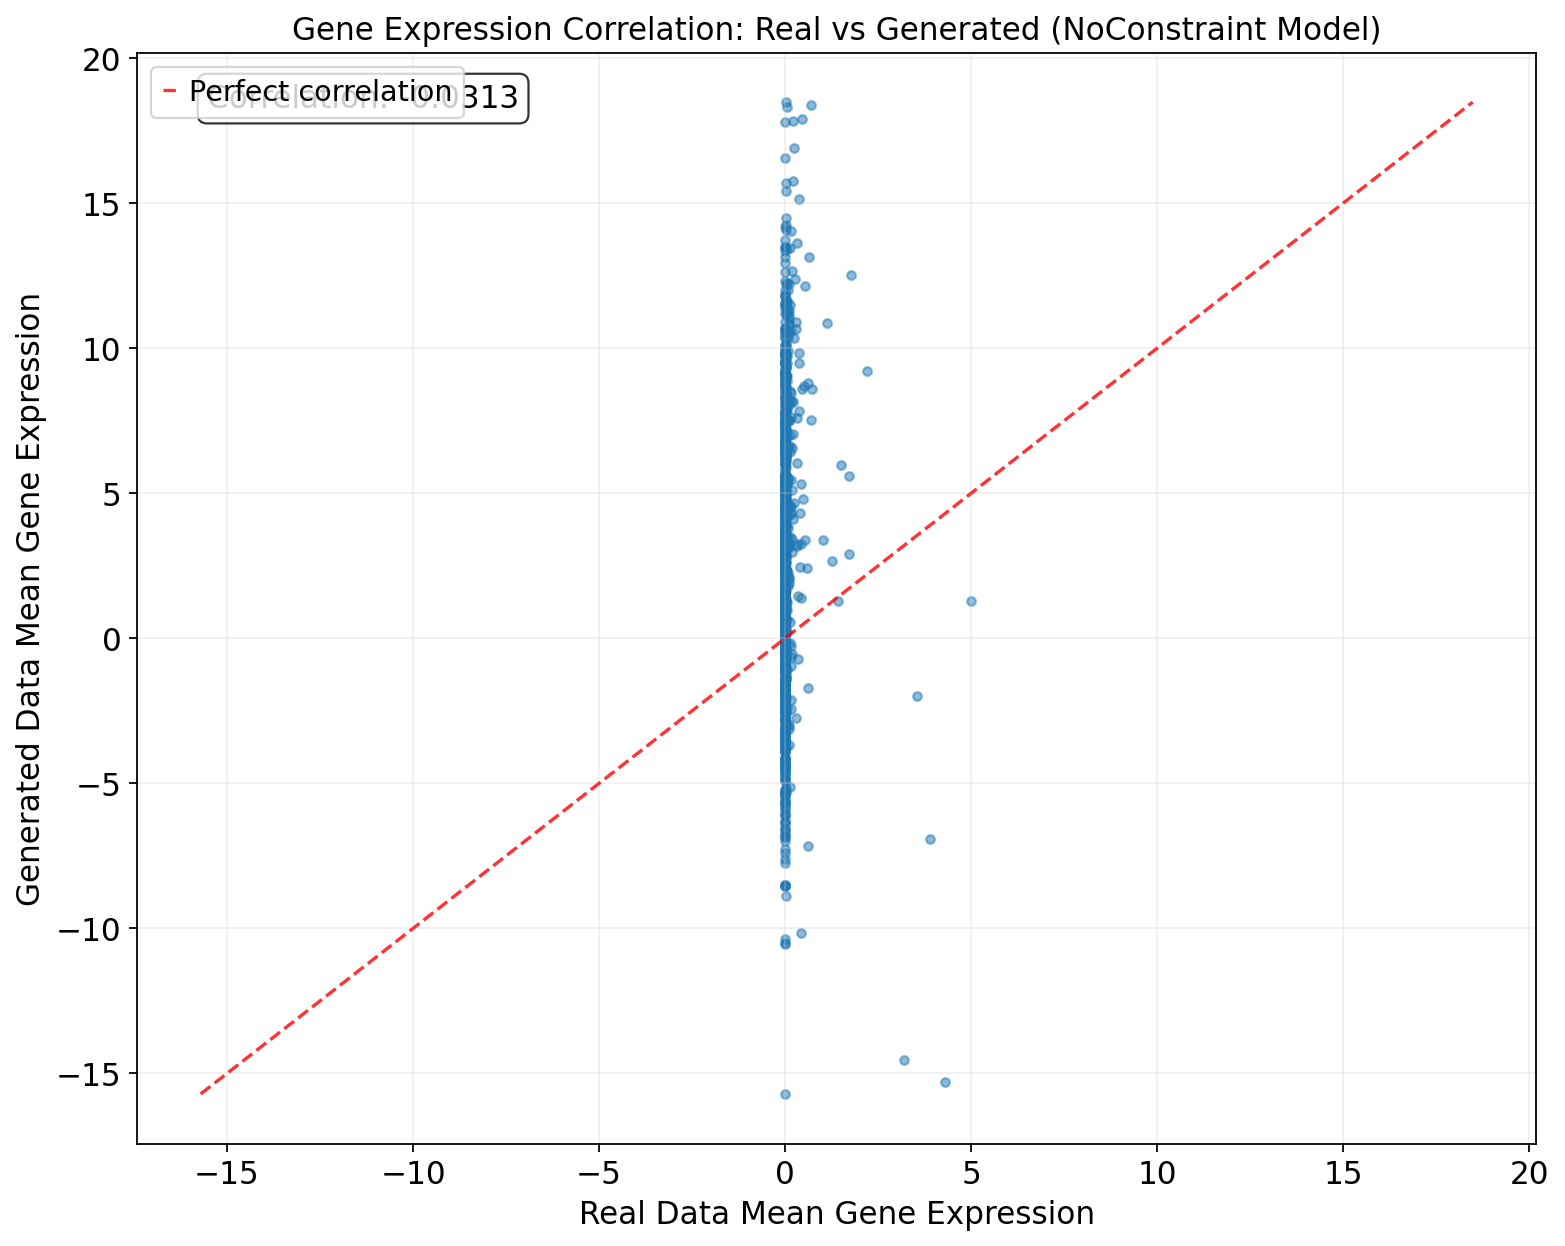

NoConstraint model generation correlation: -0.0313


In [17]:
# Analyze gene expression correlation between real and generated data
if cell_gen is not None:
    # Calculate mean expression per gene
    real_gene_means = cell_data.mean(axis=0)
    gen_gene_means = cell_gen.mean(axis=0)
    
    # Plot correlation
    plt.figure(figsize=(10, 8))
    plt.scatter(real_gene_means, gen_gene_means, alpha=0.5, s=15)
    plt.xlabel('Real Data Mean Gene Expression')
    plt.ylabel('Generated Data Mean Gene Expression')
    plt.title('Gene Expression Correlation: Real vs Generated (NoConstraint Model)')
    
    # Add diagonal line
    min_val = min(real_gene_means.min(), gen_gene_means.min())
    max_val = max(real_gene_means.max(), gen_gene_means.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect correlation')
    
    # Calculate correlation
    corr_coef = np.corrcoef(real_gene_means, gen_gene_means)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {corr_coef:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"NoConstraint model generation correlation: {corr_coef:.4f}")
else:
    print("No generated data available for correlation analysis")

In [18]:
# Create AnnData object for UMAP analysis
print("Creating combined dataset for UMAP analysis...")

if cell_gen is not None:
    # Combine real and generated data
    combined_data = np.concatenate((cell_data, cell_gen), axis=0)
    print(f"Combined data shape: {combined_data.shape}")
    
    # Create cell origin labels
    n_real = cell_data.shape[0]
    n_gen = cell_gen.shape[0]
    cell_origin = ['Real'] * n_real + ['Generated'] * n_gen
    
    # Create AnnData object
    adata_combined = sc.AnnData(X=combined_data)
    adata_combined.obs['cell_origin'] = cell_origin
    
    # Add real cell type information
    real_celltypes = adata.obs['celltype'].values
    all_celltypes = list(real_celltypes) + ['Generated'] * n_gen
    adata_combined.obs['celltype'] = all_celltypes
    
    print(f"AnnData object created: {adata_combined.shape}")
    print(f"Cell origin distribution: {adata_combined.obs['cell_origin'].value_counts()}")
    
else:
    print("Error: Generated data not available")

Creating combined dataset for UMAP analysis...
Combined data shape: (69579, 1024)


AnnData object created: (69579, 1024)
Cell origin distribution: cell_origin
Real         68579
Generated     1000
Name: count, dtype: int64


In [19]:
# Run UMAP preprocessing and analysis
print("Running UMAP analysis...")

if 'adata_combined' in locals():
    # Basic preprocessing for UMAP
    print("Scaling data...")
    sc.pp.scale(adata_combined, max_value=10)
    
    print("Running PCA...")
    sc.tl.pca(adata_combined, svd_solver='arpack', n_comps=50)
    
    print("Computing neighbors...")
    sc.pp.neighbors(adata_combined, n_neighbors=15, n_pcs=40)
    
    print("Computing UMAP...")
    sc.tl.umap(adata_combined)
    
    print("UMAP computation completed!")
    print(f"UMAP coordinates shape: {adata_combined.obsm['X_umap'].shape}")
    
else:
    print("Error: Combined data not available")

Running UMAP analysis...
Scaling data...


Running PCA...
computing PCA
    with n_comps=50
    with n_comps=50
    finished (0:00:03)
Computing neighbors...
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished (0:00:03)
Computing neighbors...
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
Computing UMAP...
computing UMAP
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
Computing UMAP...
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:37)
UMAP computation completed!
UMAP coordinates shape: (69579, 2)
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:37)
UMAP computation completed!
UMAP coordinates shape: (69579, 2)


## UMAP Visualization: Real vs Generated (NoConstraint Model)

Creating UMAP visualizations...


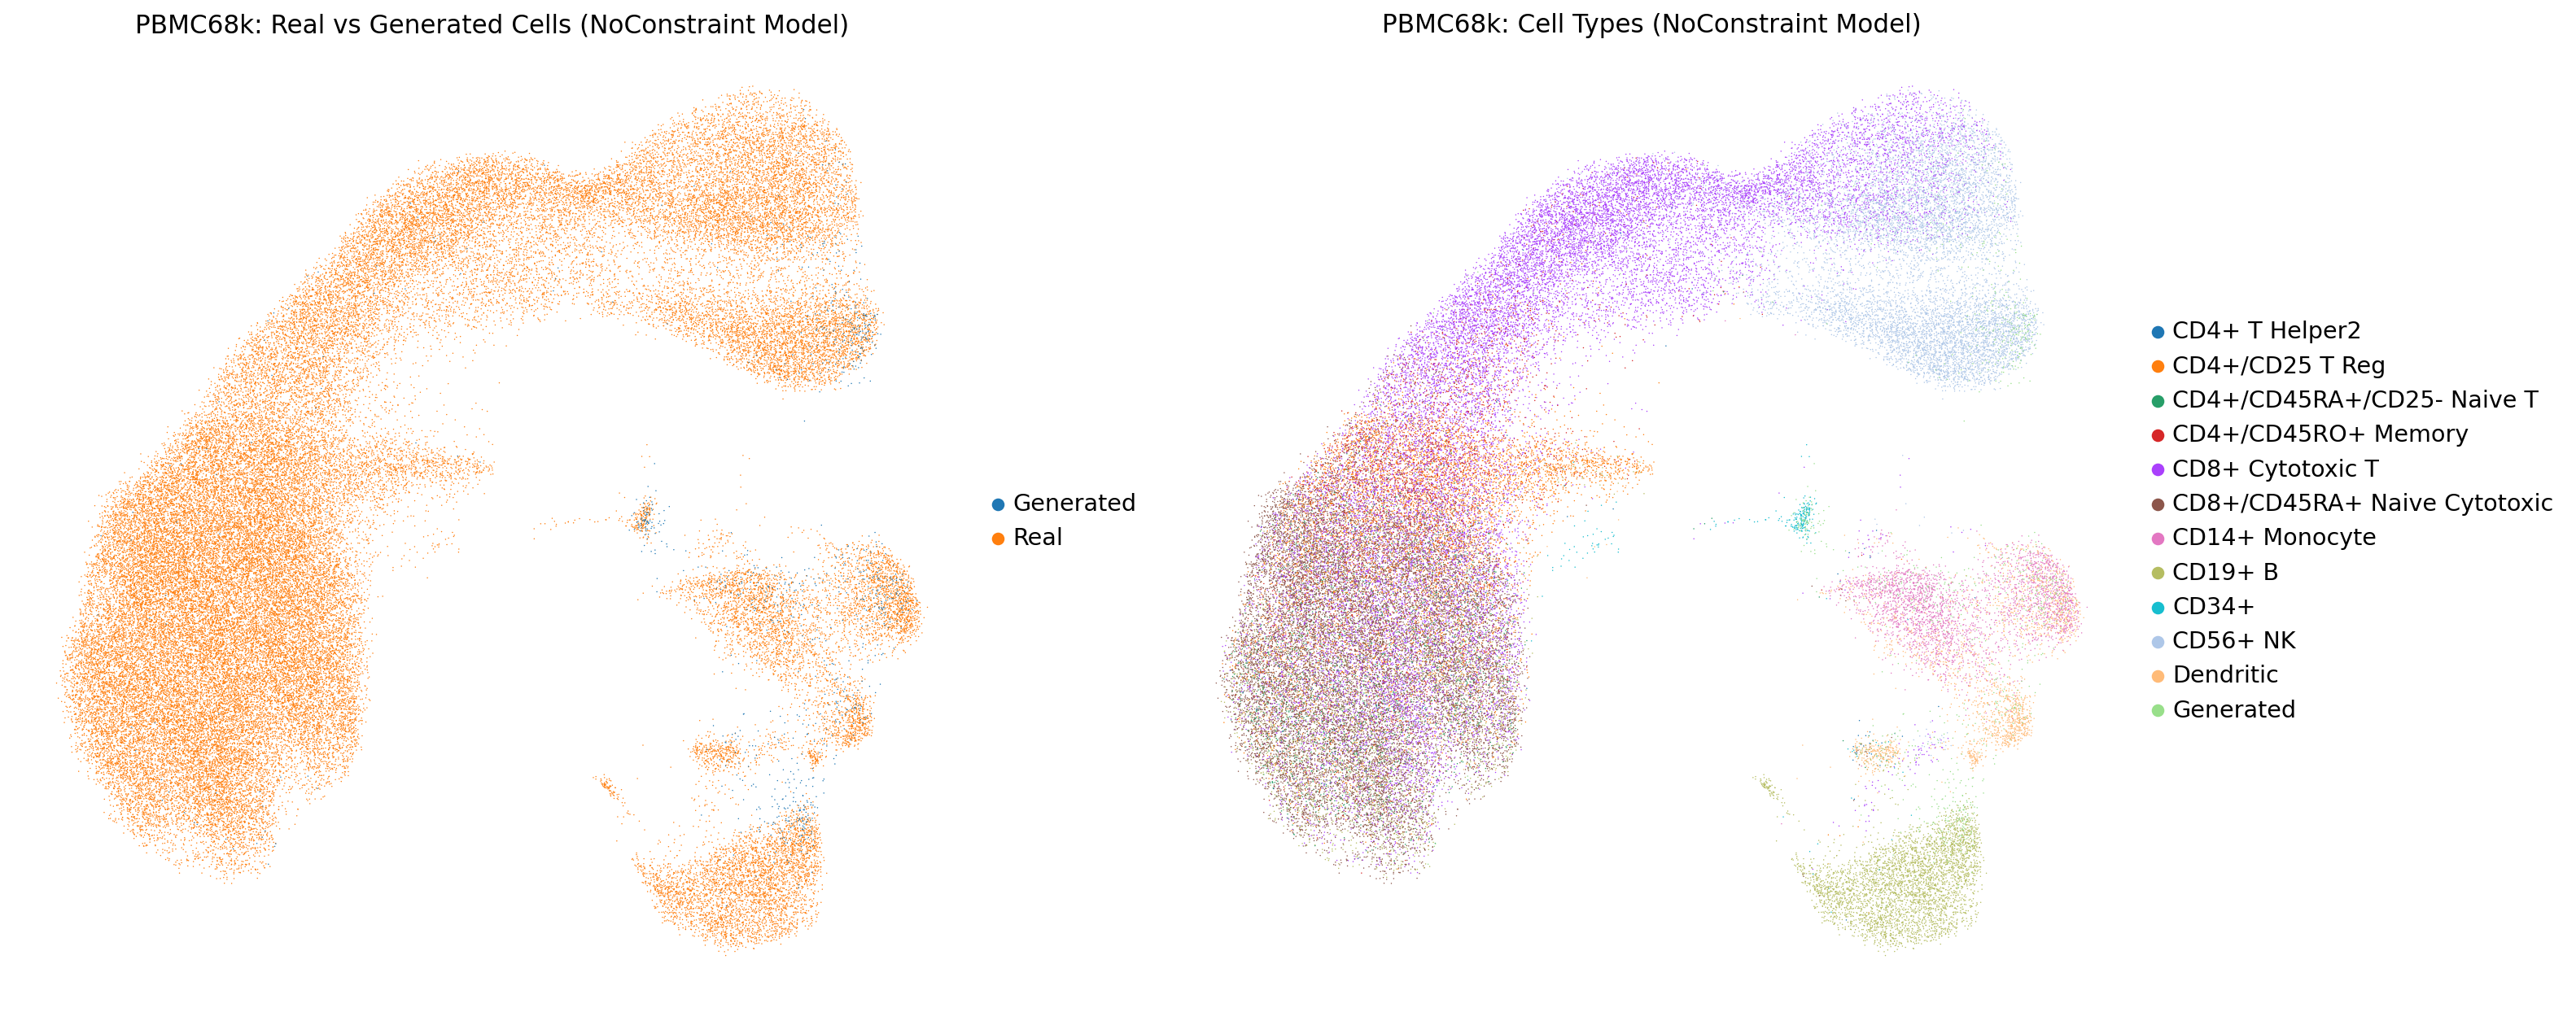

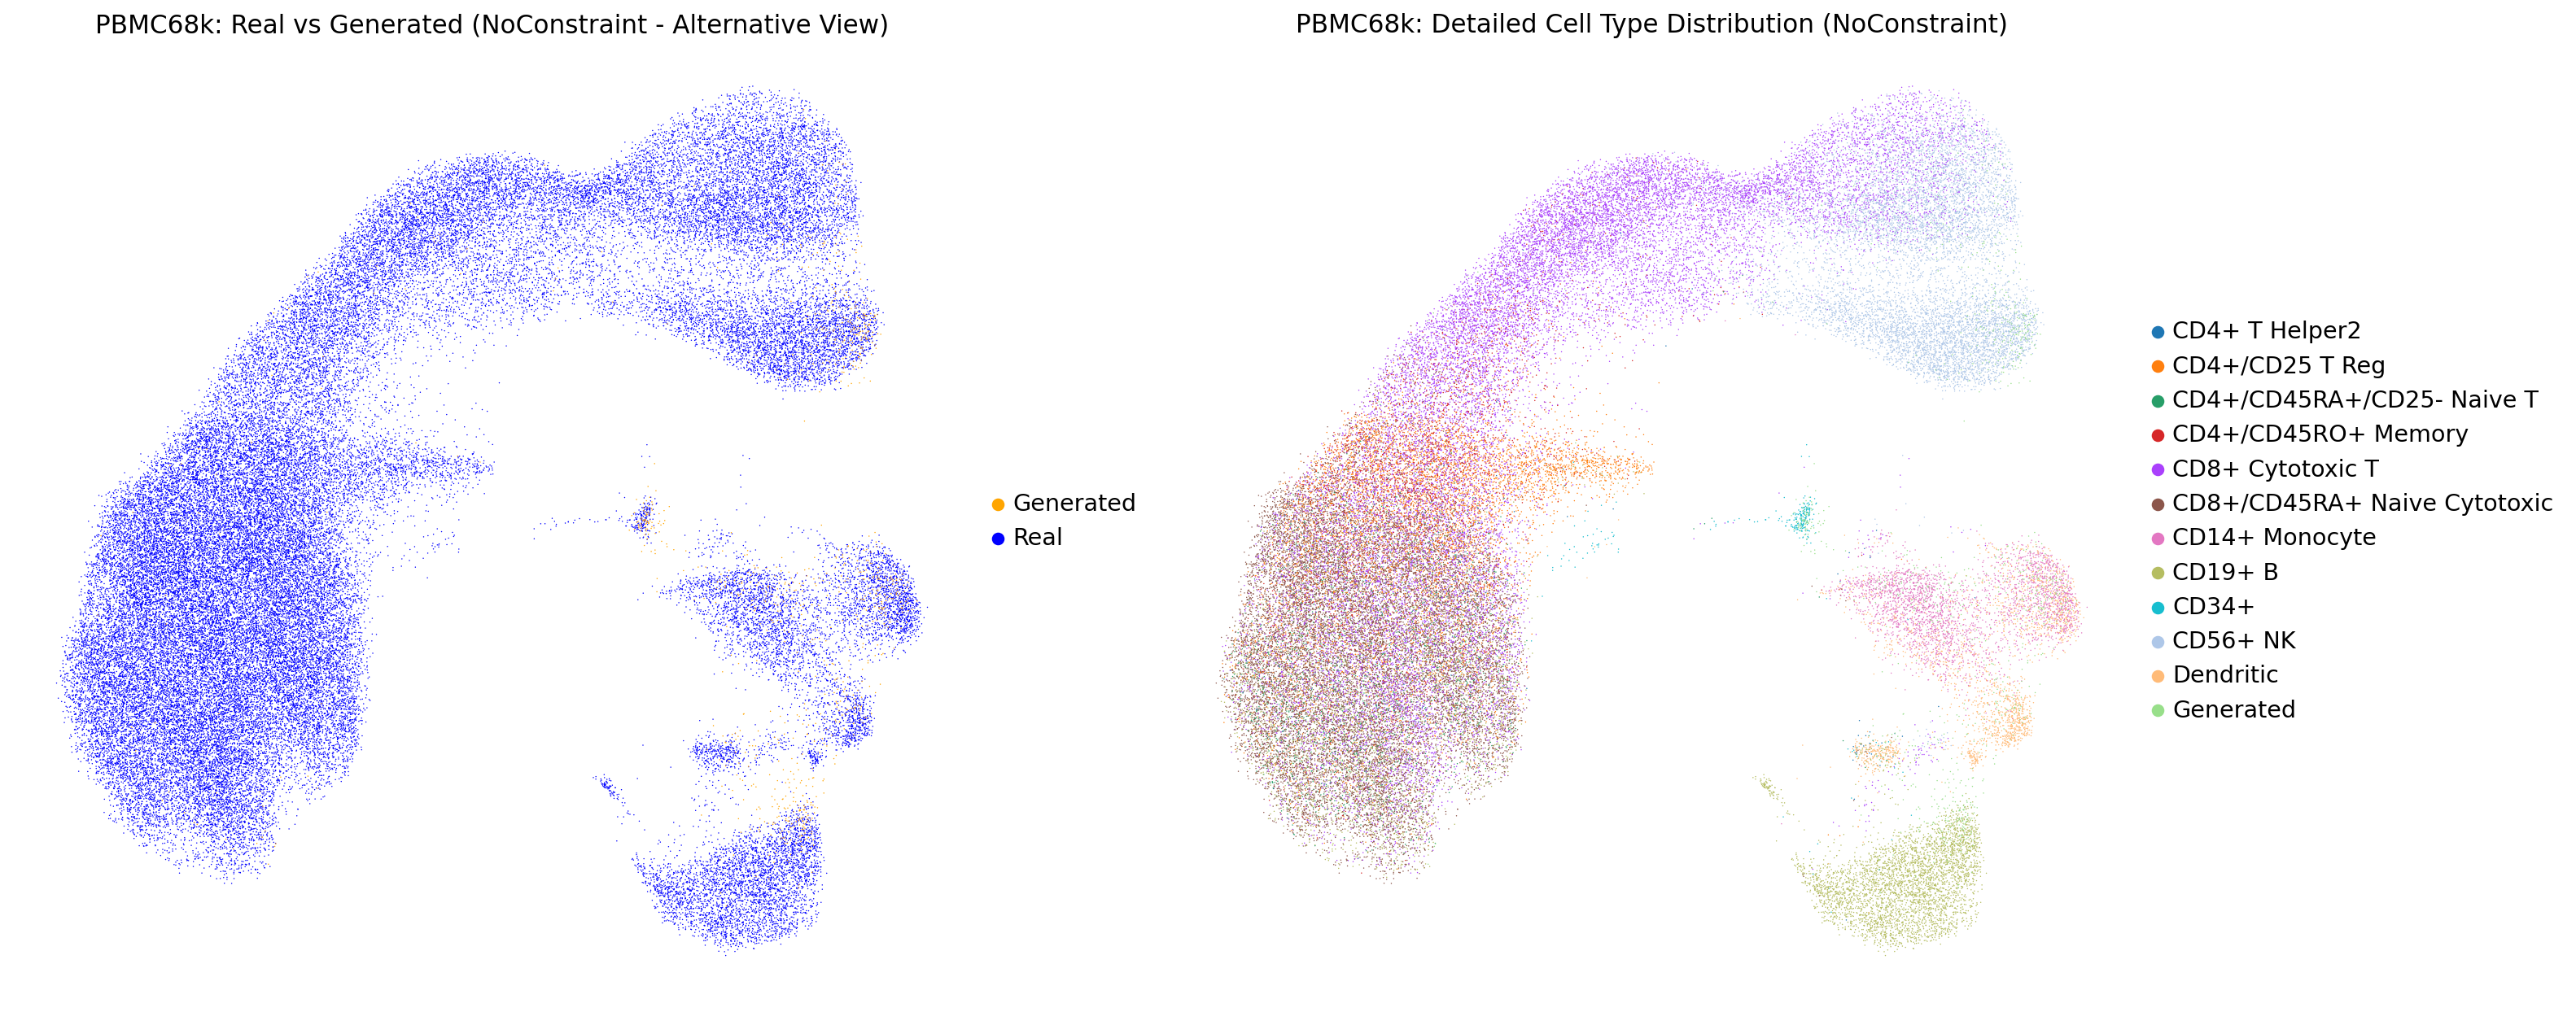

UMAP visualization completed!


In [20]:
if 'adata_combined' in locals() and 'X_umap' in adata_combined.obsm:
    print("Creating UMAP visualizations...")
    
    # Create UMAP plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Real vs Generated
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated Cells (NoConstraint Model)', 
               frameon=False, 
               show=False)
    
    # Plot 2: Cell Types
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Cell Types (NoConstraint Model)', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    # Alternative view with different color scheme
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    sc.pl.umap(adata_combined, 
               color='cell_origin', 
               palette=['orange', 'blue'], 
               ax=axes[0], 
               title='PBMC68k: Real vs Generated (NoConstraint - Alternative View)', 
               frameon=False, 
               show=False)
    
    sc.pl.umap(adata_combined, 
               color='celltype', 
               ax=axes[1], 
               title='PBMC68k: Detailed Cell Type Distribution (NoConstraint)', 
               frameon=False, 
               show=False)
    
    plt.tight_layout()
    plt.show()
    
    print("UMAP visualization completed!")
else:
    print("UMAP results not available. Please run preprocessing first.")

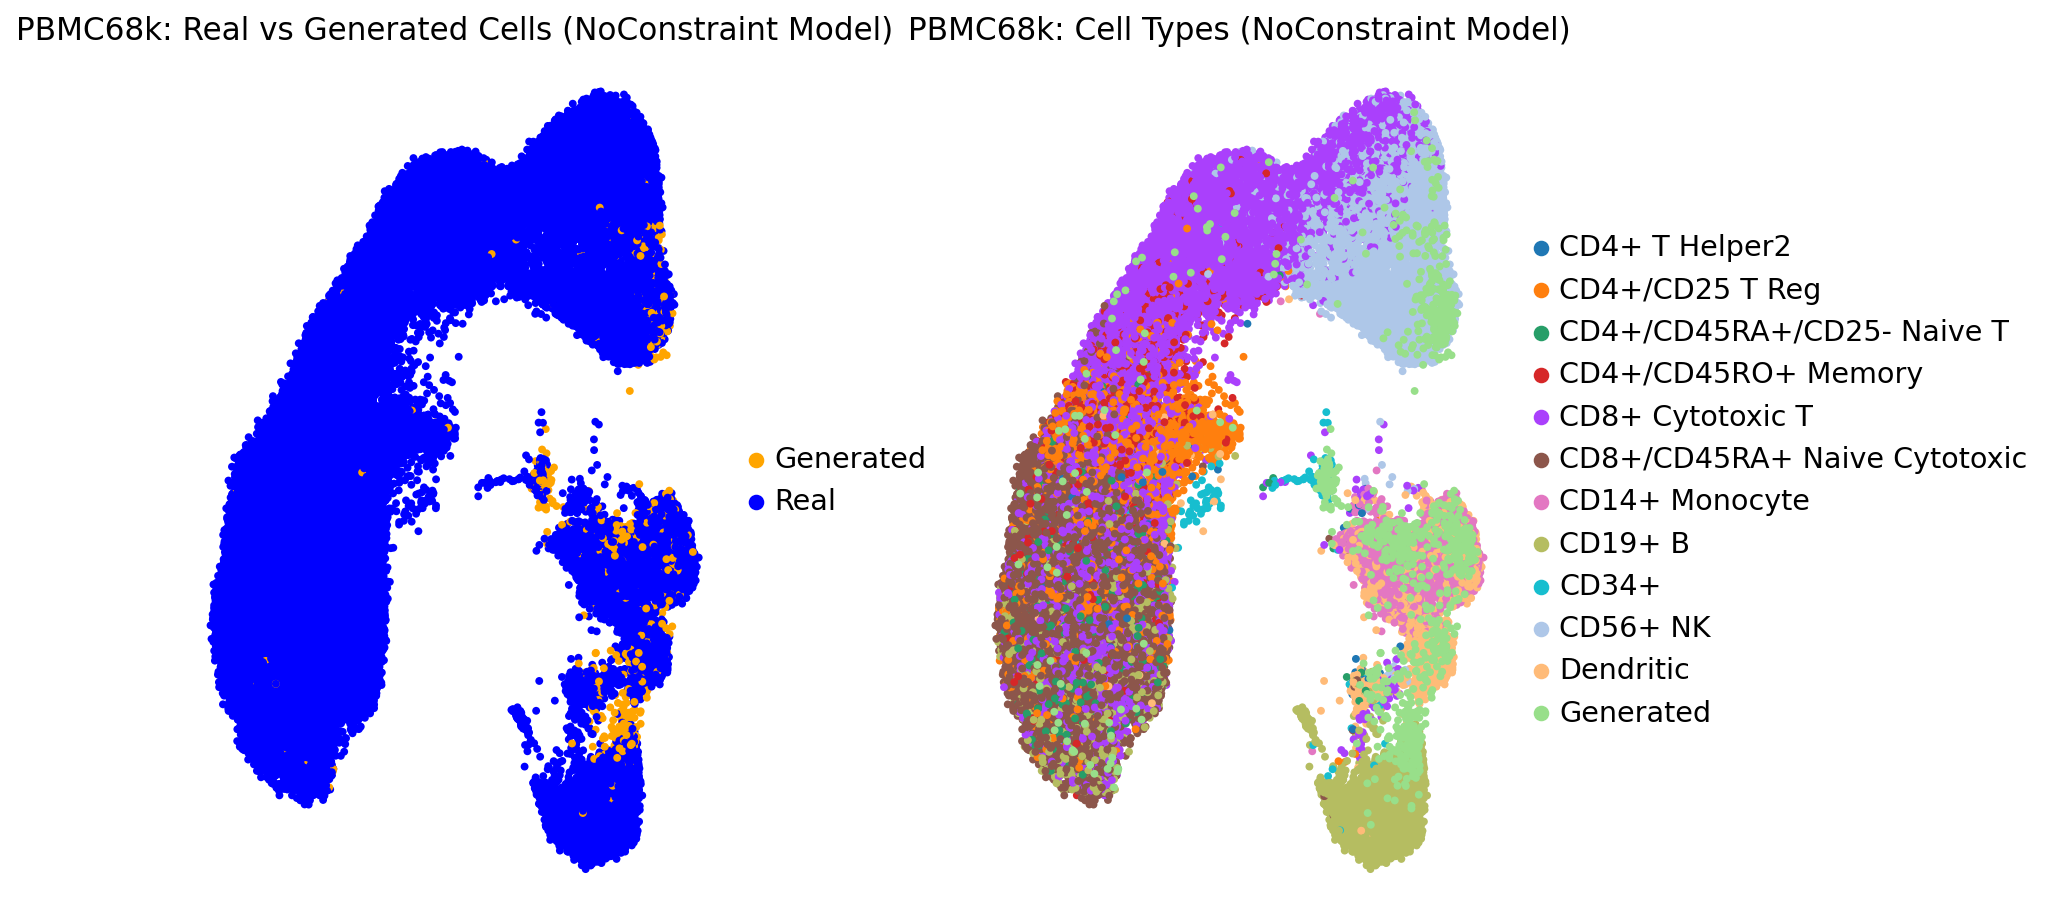

In [ ]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# 描画設定
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 左プロット：Real vs Generated（点を大きくし、重なり順をランダム化）
# 方法1：描画順シャッフル
# ランダムな順序のインデックス
indices = np.arange(adata_combined.n_obs)
np.random.shuffle(indices)
adata_shuffled = adata_combined[indices].copy()

sc.pl.umap(
    adata_shuffled,
    color='cell_origin',
    ax=axes[0],
    title='PBMC68k: Real vs Generated Cells (NoConstraint Model)',
    frameon=False,
    show=False,
    size=50,   # 点を大きく
    legend_loc='right margin'
)

# 右プロット：celltype など他のものを描きたいなら
sc.pl.umap(
    adata_combined,
    color='celltype',
    ax=axes[1],
    title='PBMC68k: Cell Types (NoConstraint Model)',
    frameon=False,
    show=False,
    size=50
)

plt.tight_layout()
plt.show()


Real subset size: 68579
Generated subset size: 1000


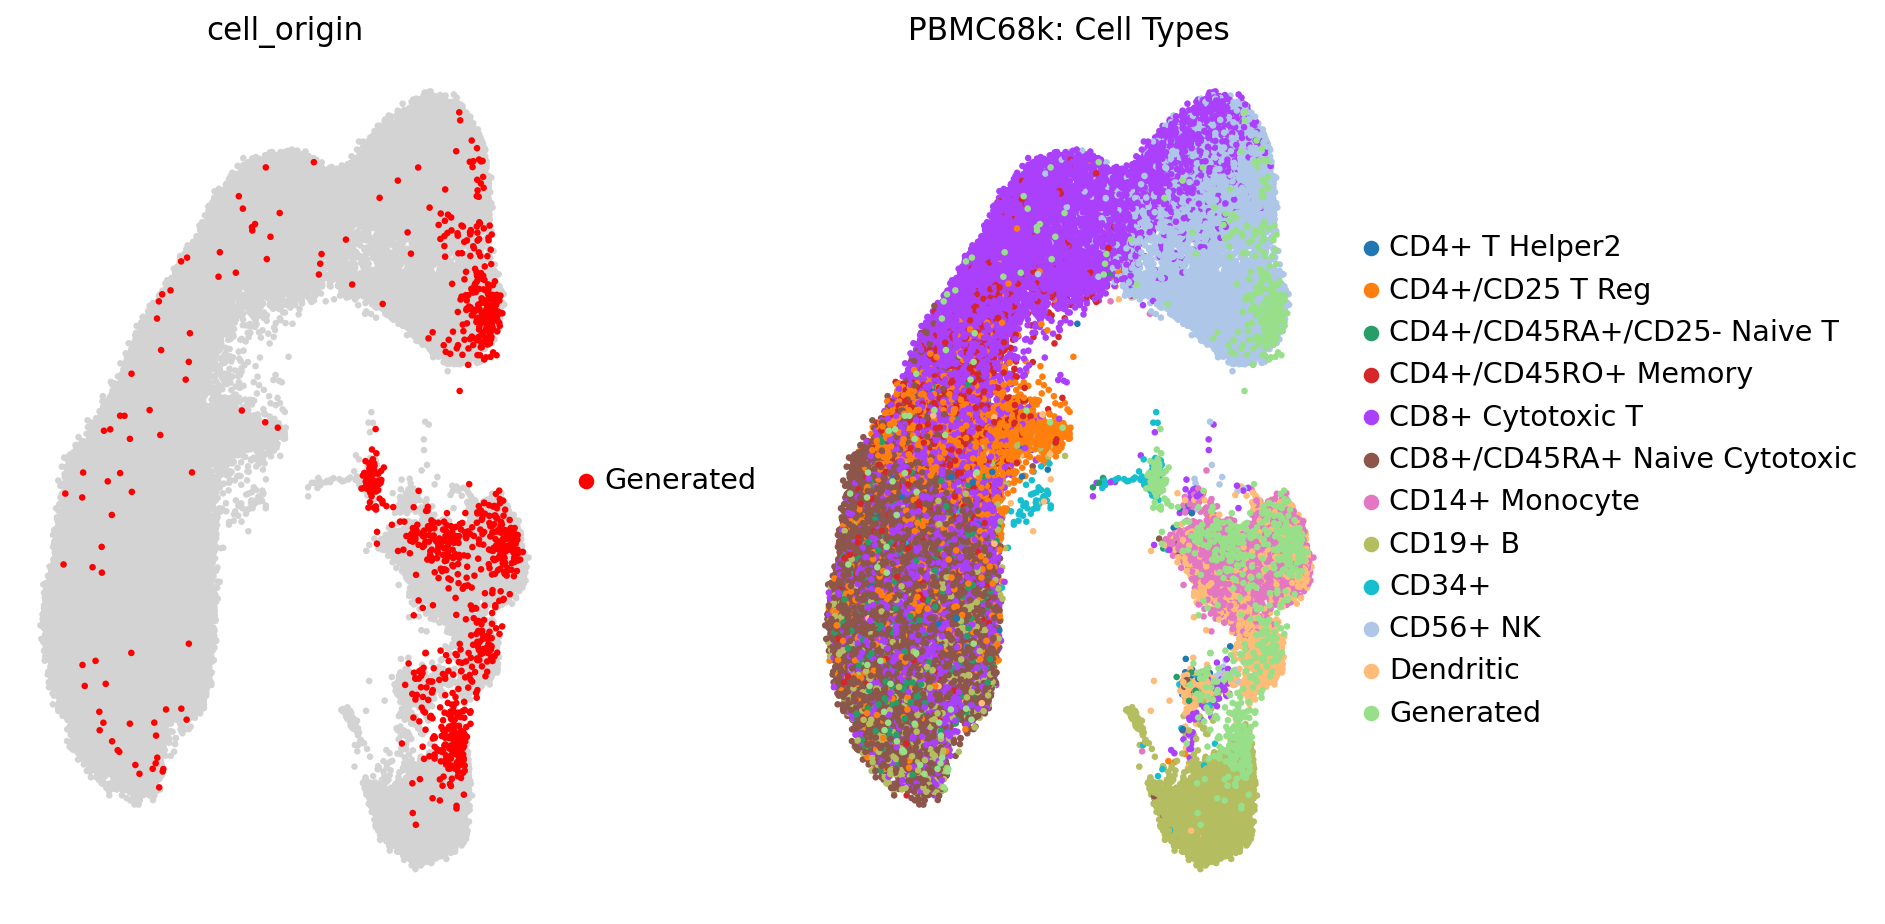

In [26]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# UMAP 座標があるかチェック
if "X_umap" not in adata_combined.obsm:
    print("X_umap が見つかりません。まず UMAP を計算します。")
    sc.tl.umap(adata_combined)

# サブプロット準備
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Real のみ
mask_real = adata_combined.obs["cell_origin"] == "Real"
adata_real = adata_combined[mask_real].copy()
print("Real subset size:", adata_real.n_obs)

# Generated のみ
mask_gen = adata_combined.obs["cell_origin"] == "Generated"
adata_gen = adata_combined[mask_gen].copy()
print("Generated subset size:", adata_gen.n_obs)

# 描画順：まず Real → 次に Generated 重ね
# （Real を薄灰色で、Generated を強調色で）

# Real をプロット（カテゴリ変数なし、灰色に統一）
if adata_real.n_obs > 0:
    # color を None にすると単色描画
    ax0 = sc.pl.umap(
        adata_real,
        color=None,
        ax=axes[0],
        frameon=False,
        show=False,
        size=35,
        # color_map で色指定は通常 continuous 用なので None を使うか無視
    )
else:
    print("Real データが空なので描画スキップ")

# Generated を上に重ねる
if adata_gen.n_obs > 0:
    # シャッフルして描画順の偏りを減らす
    idx = np.arange(adata_gen.n_obs)
    np.random.shuffle(idx)
    adata_gen = adata_gen[idx].copy()

    sc.pl.umap(
        adata_gen,
        color="cell_origin",
        ax=axes[0],
        frameon=False,
        show=False,
        size=35,
        palette={"Generated": "red"},  # Generated にだけ色を指定
        legend_loc="right margin"
    )
else:
    print("Generated データが空なので描画スキップ")

# 右側プロット：celltype
sc.pl.umap(
    adata_combined,
    color="celltype",
    ax=axes[1],
    title="PBMC68k: Cell Types",
    frameon=False,
    show=False,
    size=35
)

plt.tight_layout()
plt.show()


## Gene Network Analysis (NoConstraint Model)

In [ ]:
# Gene Network Analysis - Compare real and generated data networks
print("=== GENE NETWORK ANALYSIS (NoConstraint Model) ===")

# Import gene network metrics
import sys
sys.path.append('/home/suzuki/Projects/scDiffusion')
from metrics.gene_network_metrics import make_weighted_graph_from_adata, adjacency_correlation

if 'cell_data' in locals() and 'cell_gen' in locals():
    try:
        # Create separate AnnData objects for real and generated data
        print("Creating AnnData objects for network analysis...")
        
        # Create real data AnnData
        adata_real = sc.AnnData(X=cell_data)
        adata_real.var_names = [f"Gene_{i}" for i in range(cell_data.shape[1])]
        print(f"Real data AnnData: {adata_real.shape}")
        
        # Create generated data AnnData  
        adata_gen = sc.AnnData(X=cell_gen)
        adata_gen.var_names = [f"Gene_{i}" for i in range(cell_gen.shape[1])]
        print(f"Generated data AnnData: {adata_gen.shape}")
        
        # Ensure same gene names for comparison
        common_genes = list(set(adata_real.var_names) & set(adata_gen.var_names))
        print(f"Common genes for network analysis: {len(common_genes)}")
        
        # Subset to common genes
        adata_real_sub = adata_real[:, common_genes].copy()
        adata_gen_sub = adata_gen[:, common_genes].copy()
        
        print(f"Real data subset: {adata_real_sub.shape}")
        print(f"Generated data subset: {adata_gen_sub.shape}")
        
        # Create gene networks using PCA-based embeddings
        print("\\nCreating gene networks...")
        print("Building real data gene network...")
        graph_real = make_weighted_graph_from_adata(adata_real_sub, n_components=50)
        print(f"Real network: {graph_real.vcount()} vertices, {graph_real.ecount()} edges")
        
        print("Building generated data gene network...")
        graph_gen = make_weighted_graph_from_adata(adata_gen_sub, n_components=50)
        print(f"Generated network: {graph_gen.vcount()} vertices, {graph_gen.ecount()} edges")
        
        # Calculate network similarity
        print("\\nCalculating network similarity...")
        network_correlation = adjacency_correlation(graph_real, graph_gen)
        print(f"Gene network correlation (NoConstraint): {network_correlation:.4f}")
        
        # Additional network statistics
        print("\\n=== NETWORK STATISTICS (NoConstraint) ===")
        
        # Real network stats
        real_weights = [e["weight"] for e in graph_real.es]
        real_mean_weight = np.mean(real_weights)
        real_std_weight = np.std(real_weights)
        real_density = graph_real.density()
        
        print(f"Real network:")
        print(f"  Mean edge weight: {real_mean_weight:.4f}")
        print(f"  Std edge weight: {real_std_weight:.4f}")
        print(f"  Network density: {real_density:.4f}")
        
        # Generated network stats
        gen_weights = [e["weight"] for e in graph_gen.es]
        gen_mean_weight = np.mean(gen_weights)
        gen_std_weight = np.std(gen_weights)
        gen_density = graph_gen.density()
        
        print(f"Generated network:")
        print(f"  Mean edge weight: {gen_mean_weight:.4f}")
        print(f"  Std edge weight: {gen_std_weight:.4f}")
        print(f"  Network density: {gen_density:.4f}")
        
        # Weight distribution comparison
        print(f"\\nWeight distribution comparison:")
        print(f"  Weight correlation: {np.corrcoef(real_weights, gen_weights)[0,1]:.4f}")
        print(f"  Weight difference (mean): {abs(real_mean_weight - gen_mean_weight):.4f}")
        print(f"  Weight difference (std): {abs(real_std_weight - gen_std_weight):.4f}")
        
        print("\\nGene network analysis completed!")
        
    except Exception as e:
        print(f"Error in gene network analysis: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("Error: cell_data or cell_gen not available for network analysis")

=== GENE NETWORK ANALYSIS (NoConstraint Model) ===
Creating AnnData objects for network analysis...
Real data AnnData: (68579, 17789)
Generated data AnnData: (3000, 17789)
Common genes for network analysis: 17789
Real data subset: (68579, 17789)
Generated data subset: (3000, 17789)
\nCreating gene networks...
Building real data gene network...


KeyboardInterrupt: 

In [ ]:
adata_combined.obs["celltype"].unique()

In [ ]:
# Separate cells based on whether celltype starts with "gen"
gen_mask = adata_combined.obs["celltype"].str.startswith("gen")
non_gen_mask = ~gen_mask

print(f"Cells with 'gen' celltype: {gen_mask.sum()}")
print(f"Cells without 'gen' celltype: {non_gen_mask.sum()}")

# Create separate AnnData objects
adata_gen = adata_combined[gen_mask].copy()
adata_non_gen = adata_combined[non_gen_mask].copy()

print(f"Generated cells data shape: {adata_gen.shape}")
print(f"Real cells data shape: {adata_non_gen.shape}")

# Create UMAP plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# UMAP for generated cells (starting with "gen")
sc.pl.umap(adata_gen, 
           color='celltype', 
           ax=axes[0], 
           title='Generated Cells (NoConstraint Model)', 
           frameon=False, 
           show=False)

# UMAP for real cells (not starting with "gen")
sc.pl.umap(adata_non_gen, 
           color='celltype', 
           ax=axes[1], 
           title='Real Cells (NoConstraint Model)', 
           frameon=False, 
           show=False)

plt.tight_layout()
plt.show()

# Create PCA plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA for generated cells (starting with "gen")
sc.pl.pca(adata_gen, 
          color='celltype', 
          ax=axes[0], 
          title='Generated Cells PCA (NoConstraint Model)', 
          frameon=False, 
          show=False)

# PCA for real cells (not starting with "gen")
sc.pl.pca(adata_non_gen, 
          color='celltype', 
          ax=axes[1], 
          title='Real Cells PCA (NoConstraint Model)', 
          frameon=False, 
          show=False)

plt.tight_layout()
plt.show()

print("UMAP and PCA plots created for generated vs real cells (NoConstraint Model)!")

In [ ]:
from itertools import chain

# ──────────────────────────────────────────────────────────
# 0. 前提: adata_combined には
#    obs["celltype"] = 〔実細胞クラスタ〕 ∪ 〔"gen " + 実クラスタ〕 が入っている
# ──────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────
# 1. 実クラスタのみ取り出してマーカー遺伝子解析
# ──────────────────────────────────────────────────────────
is_real = ~adata_combined.obs["celltype"].str.startswith("gen")
adata_real = adata_combined[is_real].copy()   # ★ 解析対象は実細胞のみ

sc.tl.rank_genes_groups(
    adata_real,
    groupby      = "celltype",           # クラスタ列
    reference    = "rest",               # 各クラスタ vs. 残り全部
    method       = "wilcoxon",
    n_genes      = adata_real.shape[1]   # すべての遺伝子で検定
)

# ──────────────────────────────────────────────────────────
# 2. 各クラスタで P_adj < 0.001 かつ |logFC| が大きい
#    上位 20 遺伝子を抜き出し辞書にまとめる
# ──────────────────────────────────────────────────────────

marker_dict = {}                         # {cluster: [gene1, …, gene20]}
for clust in adata_real.obs["celltype"].cat.categories:
    df = sc.get.rank_genes_groups_df(adata_real, group=clust)              # 全遺伝子
    df["logfoldchanges_abs"] =df["logfoldchanges"].abs()
    df.sort_values("logfoldchanges_abs", ascending=False, inplace=True)  # |logFC| 降順
    df = df[df["pvals_adj"] < 0.05]                                       # P_adj < 0.001
                                                  # 上位
    top20 = df.head(20)["names"].tolist()
    marker_dict[clust] = top20
    print(clust)
    print(len(top20))
#==========================================================

"""
per‑cluster MATRIXPLOT (2×1: real / gen) を
カレントディレクトリ直下  cluster_plots/ に保存する (NoConstraint Model)
────────────────────────────────────────────
前提:
    • adata_combined : 実＋生成 AnnData
    • marker_dict    : {cluster_name: [top‑20 genes…]}  ← ①‑② で作成済み
"""

import os, re, scanpy as sc, matplotlib.pyplot as plt

# ───────────────────────────────────────────
# 0. 保存先ディレクトリを scanpy のデフォルトに設定
# ───────────────────────────────────────────
FIGDIR = os.path.join(os.getcwd(), "cluster_plots_NoConstraint")
os.makedirs(FIGDIR, exist_ok=True)
sc.settings.figdir = FIGDIR          # save= の既定出力先

def sanitize(name: str) -> str:
    """ファイル名に使えない文字を _ に置換"""
    return re.sub(r"[^\w\-]", "_", name)

# パラメータ
GENES_PER_CLUSTER = 20
real_clusters     = list(marker_dict.keys())

# ───────────────────────────────────────────
# 1. 各クラスタで 2×1 subplot を作成
# ───────────────────────────────────────────
for clust in real_clusters:
    gen_label = f"gen {clust}"
    genes_all = marker_dict[clust][:GENES_PER_CLUSTER]

    # ── Figure / Axes 作成 ───────────────────────────
    fig, axes = plt.subplots(
        nrows   = 2, ncols = 1,
        figsize = (8, 6),
        sharex  = False, sharey=False
    )

    # ── 0 行目: real sample ──────────────────────────
    sc.pl.matrixplot(
        adata_combined[is_real],
        var_names      = genes_all,
        groupby        = "celltype",
        cmap           = "bwr",
        standard_scale = "var",
        dendrogram     = False,
        swap_axes      = False,          # 列＝遺伝子・行＝celltype(=1 行)
        show           = False,
        ax             = axes[0],        # ← subplot 指定
    )

    # ── 1 行目: generated sample ─────────────────────
    sc.pl.matrixplot(
        adata_combined[~is_real],
        var_names      = genes_all,
        groupby        = "celltype",
        cmap           = "bwr",
        standard_scale = "var",
        dendrogram     = False,
        swap_axes      = False,
        show           = False,
        ax             = axes[1],
    )

    plt.tight_layout(h_pad=1.2)
    save_path = os.path.join(FIGDIR, f"{sanitize(clust)}_NoConstraint_dual_matrixplot.png")
    fig.savefig(save_path, dpi=300)
    plt.close(fig)

    print(f"✔  saved {save_path}")

print(f"✔  全クラスタの図を {FIGDIR} に保存しました。")

In [ ]:
adata_real

In [ ]:
adata_gen

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import igraph as ig

# 1) adata → 重み付きグラフ（頂点に embedding を保存）
def make_weighted_graph_from_adata(adata, n_components=50):
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X   # (cells × genes)
    genes = np.array(adata.var_names)
    Xt = X.T  # (genes × cells)

    pca = PCA(n_components=n_components)
    emb = pca.fit_transform(Xt)   # (genes × 50)

    sim = cosine_similarity(emb)  # 類似度を重みとして使う（[-1,1]）

    g = ig.Graph.Weighted_Adjacency(sim.tolist(), mode="undirected", attr="weight", loops=False)
    g.vs["name"] = genes.tolist()
    # ← これが無いと後で KeyError になる
    g.vs["embedding"] = [e.tolist() for e in emb]

    return g

# 2) 2グラフの埋め込み類似度（共通遺伝子に揃えて平均コサイン）
def graph_embedding_similarity(g1, g2):
    # gene名で対応付け
    names1 = np.array(g1.vs["name"]); names2 = np.array(g2.vs["name"])
    common = np.intersect1d(names1, names2)
    if common.size == 0:
        raise ValueError("共通遺伝子がありません。")

    # 頂点順に注意：名前→インデックスの辞書で揃える
    idx1 = [g1.vs.find(name=n).index for n in common]
    idx2 = [g2.vs.find(name=n).index for n in common]

    emb1 = np.array(g1.vs["embedding"])[idx1]
    emb2 = np.array(g2.vs["embedding"])[idx2]

    # 共通遺伝子間で対応する行同士のコサインを平均
    # （別案：全対全コサインの平均/Top-k 平均なども可）
    num = np.sum(emb1 * emb2, axis=1)
    den = (np.linalg.norm(emb1, axis=1) * np.linalg.norm(emb2, axis=1) + 1e-12)
    per_gene_cos = num / den
    return float(np.mean(per_gene_cos))

# 3) 2グラフを共通遺伝子に揃えてLeiden→クラスタ一致度（ARI/NMI）
def compare_graphs_by_communities(g1, g2, resolution=1.0):
    # 共通遺伝子にサブグラフ化（順序を明示的に合わせる）
    names1 = np.array(g1.vs["name"]); names2 = np.array(g2.vs["name"])
    common = np.intersect1d(names1, names2)
    if common.size == 0:
        raise ValueError("共通遺伝子がありません。")

    # g1, g2 ともに common の順に頂点を並べ替え
    g1_sub = g1.subgraph([g1.vs.find(name=n).index for n in common])
    g2_sub = g2.subgraph([g2.vs.find(name=n).index for n in common])

    # Leiden（重み使用）
    c1 = g1_sub.community_leiden(weights="weight", resolution_parameter=resolution)
    c2 = g2_sub.community_leiden(weights="weight", resolution_parameter=resolution)

    labels1 = c1.membership
    labels2 = c2.membership

    # 一致度
    ari = adjusted_rand_score(labels1, labels2)
    nmi = normalized_mutual_info_score(labels1, labels2)

    return {
        "genes": common,            # 比較に使った遺伝子順
        "partition1": c1,           # igraph.VertexClustering
        "partition2": c2,           # igraph.VertexClustering
        "ari": float(ari),
        "nmi": float(nmi),
    }

In [ ]:
g_real = make_weighted_graph_from_adata(adata_real, n_components=50)
g_gen  = make_weighted_graph_from_adata(adata_gen,  n_components=50)

# 埋め込みレベルの近さ（共通遺伝子で平均コサイン）
sim_score = graph_embedding_similarity(g_real, g_gen)
print("Embedding similarity (mean cosine) - NoConstraint Model:", sim_score)

# コミュニティ（Leiden）一致度
res = compare_graphs_by_communities(g_real, g_gen, resolution=1.0)
print("ARI:", res["ari"], "NMI:", res["nmi"], "#genes:", len(res["genes"]))